In [56]:
import os
import sys

import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import healsparse as hs

txpipe_dir = os.path.join(os.environ["HOME"], "TXPipe")
sys.path.append(txpipe_dir)
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

from txpipe.random_cats import TXRandomCat
import ceci

# will want to try this using different exposure/depth maps, could be whats driving this

In [2]:
def print_hdf5_structure(file='/global/homes/k/kabelo/TXPipe/data/example/inputs/photometry_catalog.hdf5'):
    with h5py.File(file, 'r') as f:
        print("Keys in the HDF5 file:")
        def print_structure(name, obj):
            print(f"{name}: {type(obj).__name__}")
        f.visititems(print_structure)

def hdf5_to_df(file='/global/homes/k/kabelo/TXPipe/data/example/inputs/photometry_catalog.hdf5', group=None):
    with h5py.File(file, 'r') as f:
        data_dict = {}
        if group:
            for k in f[group].keys():
                data_dict[k] = f[group][k][:]
        else:
            for k in f.keys():
                if k != 'provenance':
                    group = k
            for k in f[group].keys():
                data_dict[k] = f[group][k][:]
        df = pd.DataFrame(data_dict)
    return df

In [52]:
photometry = hdf5_to_df()
photometry['snr_i'].mean(), photometry['snr_i'].median(), photometry['snr_i'].max(), photometry['snr_i'].min()

(np.float64(33.329831672344135),
 np.float64(6.17336986169975),
 np.float64(18484.96498472502),
 np.float64(0.0))

In [59]:
clusters = hdf5_to_df('/global/homes/k/kabelo/TXPipe/data/example/inputs/photometry_catalog.hdf5')
clusters

,dec,extendedness,g_mag,g_mag_err,i_mag,i_mag_err,id,mag_err_g,mag_err_i,mag_err_r,...,snr_r,snr_u,snr_y,snr_z,u_mag,u_mag_err,y_mag,y_mag_err,z_mag,z_mag_err
0,-30.012834,1.0,20.487791,0.000709,20.052046,0.000993,3437500079,0.000709,0.000993,0.000811,...,1338.499233,216.774744,314.328004,669.346694,21.672545,0.005009,19.952085,0.003454,20.004635,0.001622
1,-30.097206,1.0,20.976517,0.001112,20.385608,0.001350,3437500084,0.001112,0.001350,0.001168,...,929.228664,165.815166,244.627423,511.324500,21.963506,0.006548,20.224280,0.004438,20.297021,0.002123
2,-30.752347,1.0,20.558272,0.000757,19.899142,0.000863,3437500174,0.000757,0.000863,0.000764,...,1420.723170,239.118300,397.576052,823.847951,21.566034,0.004541,19.696992,0.002731,19.779145,0.001318
3,-30.118557,1.0,21.847921,0.002482,21.314772,0.003178,3437500194,0.002482,0.003178,0.002681,...,404.995064,64.666690,97.737066,208.783015,22.985865,0.016790,21.220395,0.011109,21.269525,0.005200
4,-30.962028,1.0,17.834691,0.000062,17.170484,0.000070,3437500209,0.000062,0.000070,0.000062,...,17557.217076,2977.283470,4906.622419,10185.840850,18.828016,0.000365,16.968586,0.000221,17.048770,0.000107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82195,-30.958562,1.0,26.325488,0.153381,inf,0.346437,4269515710,0.153381,0.346437,0.213319,...,5.089727,0.000000,0.000000,0.000000,inf,0.700214,inf,1.466279,inf,0.606150
82196,-30.947296,1.0,26.759665,0.228793,26.100601,0.260884,4269524754,0.228793,0.260884,0.250632,...,4.332000,0.000000,0.000000,0.000000,inf,1.698531,inf,0.856968,inf,0.376713
82197,-30.998789,1.0,26.017029,0.115449,25.702212,0.180756,4270145553,0.115449,0.180756,0.119185,...,9.109664,0.000000,0.000000,0.000000,inf,1.994317,inf,0.719946,inf,0.327976
82198,-30.980917,1.0,26.903624,0.261232,inf,0.483739,4270573215,0.261232,0.483739,0.333536,...,0.000000,0.000000,0.000000,0.000000,inf,1.563855,inf,2.222618,inf,0.868679


In [11]:
!ceci /global/homes/k/kabelo/TXPipe/examples/randoms/long_randoms_pipeline.yml


Executing TXAuxiliaryLensMaps
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXAuxiliaryLensMaps   --photometry_catalog=data/example/inputs/photometry_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --aux_lens_maps=data/example/outputs_randoms_snr25/aux_lens_maps.hdf5 
Output writing to examples/randoms/logs/TXAuxiliaryLensMaps.out

Job TXAuxiliaryLensMaps has completed successfully in 3.0 seconds

Executing TXStarCatalogSplitter
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXStarCatalogSplitter   --star_catalog=data/example/inputs/star_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --binned_star_catalog=data/example/outputs_randoms_snr25/binned_star_catalog.hdf5 
Output writing to examples/randoms/logs/TXStarCatalogSplitter.out

Job TXStarCatalogSplitter has completed successfully in 2.0 seconds

Executing FlowCreator
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=subm

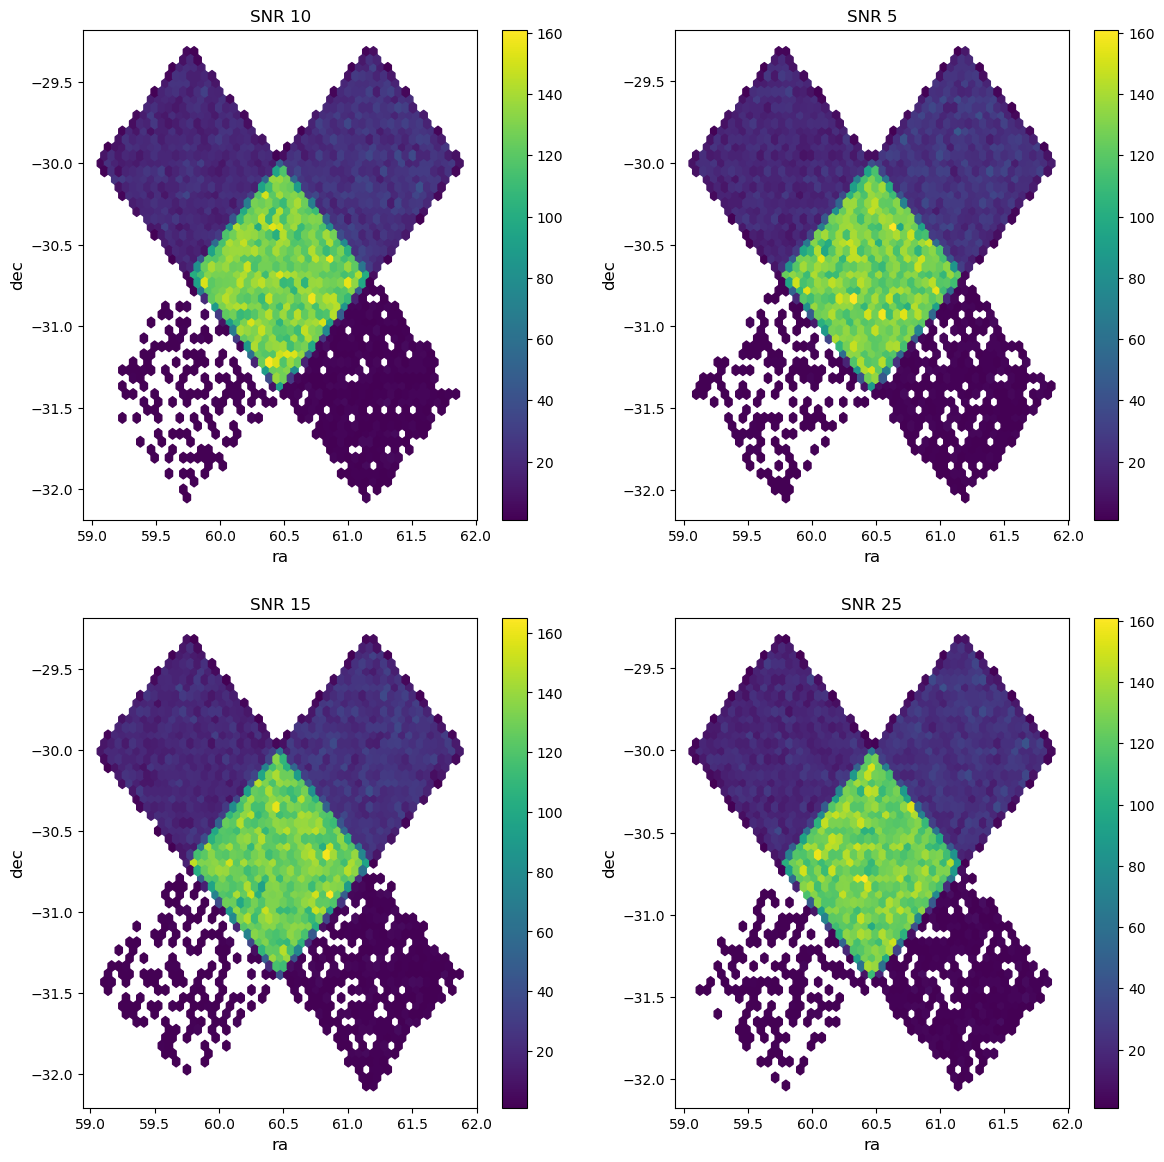

In [16]:

fig, axs = plt.subplots(2, 2, figsize=(14, 14))
f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[0, 0].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[0, 0])
axs[0, 0].set_xlabel('ra', fontsize=12)
axs[0, 0].set_ylabel('dec', fontsize=12)
axs[0, 0].set_title('SNR 10')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_snr5/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[0, 1].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[0, 1])
axs[0, 1].set_xlabel('ra', fontsize=12)
axs[0, 1].set_ylabel('dec', fontsize=12)
axs[0, 1].set_title('SNR 5')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_snr15/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[1, 0].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[1, 0])
axs[1, 0].set_xlabel('ra', fontsize=12)
axs[1, 0].set_ylabel('dec', fontsize=12)
axs[1, 0].set_title('SNR 15')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_snr25/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[1, 1].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[1, 1])
axs[1, 1].set_xlabel('ra', fontsize=12)
axs[1, 1].set_ylabel('dec', fontsize=12)
axs[1, 1].set_title('SNR 25')
plt.show()

In [24]:
!ceci /global/homes/k/kabelo/TXPipe/examples/randoms/long_randoms_pipeline.yml


Executing TXAuxiliaryLensMaps
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXAuxiliaryLensMaps   --photometry_catalog=data/example/inputs/photometry_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --aux_lens_maps=data/example/outputs_randoms_nside128/aux_lens_maps.hdf5 
Output writing to examples/randoms/logs/TXAuxiliaryLensMaps.out

Job TXAuxiliaryLensMaps has completed successfully in 10.0 seconds

Executing TXStarCatalogSplitter
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXStarCatalogSplitter   --star_catalog=data/example/inputs/star_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --binned_star_catalog=data/example/outputs_randoms_nside128/binned_star_catalog.hdf5 
Output writing to examples/randoms/logs/TXStarCatalogSplitter.out

Job TXStarCatalogSplitter has completed successfully in 2.0 seconds

Executing FlowCreator
Command is:
OMP_NUM_THREADS=1 PYTHONPA

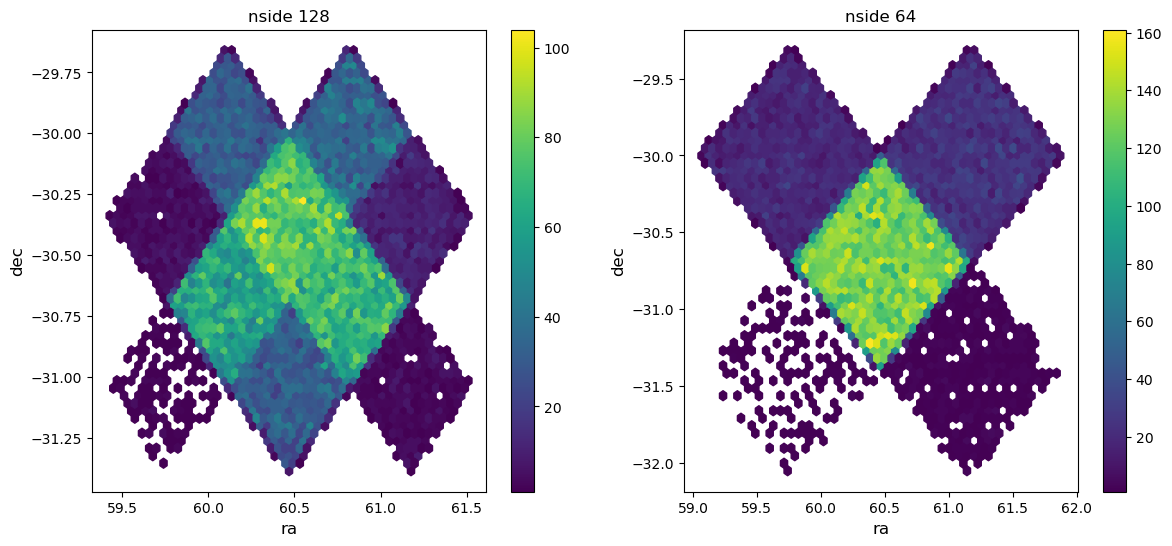

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_nside128/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[0].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[0])
axs[0].set_xlabel('ra', fontsize=12)
axs[0].set_ylabel('dec', fontsize=12)
axs[0].set_title('nside 128')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[1].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[1])
axs[1].set_xlabel('ra', fontsize=12)
axs[1].set_ylabel('dec', fontsize=12)
axs[1].set_title('nside 64')

plt.show()

# Clusters

In [57]:
print_hdf5_structure('/global/homes/k/kabelo/TXPipe/data/example/inputs/cluster_catalog.hdf5')

Keys in the HDF5 file:
clusters: Group
clusters/cluster_id: Dataset
clusters/dec: Dataset
clusters/ra: Dataset
clusters/redshift: Dataset
clusters/redshift_err: Dataset
clusters/richness: Dataset
clusters/richness_err: Dataset
clusters/scaleval: Dataset
provenance: Group


In [58]:
clusters = hdf5_to_df('/global/homes/k/kabelo/TXPipe/data/example/inputs/cluster_catalog.hdf5')
clusters

,cluster_id,dec,ra,redshift,redshift_err,richness,richness_err,scaleval
0,11,-30.895867,60.696673,0.499300,0.002938,167.656387,2.991757,0.999967
1,827,-30.234969,60.246841,0.646019,0.007420,50.269356,2.662297,1.001042
2,1985,-30.155166,60.330376,0.641010,0.007959,31.856600,2.070647,1.000236
3,1632,-30.288559,60.197986,0.658747,0.008534,13.748945,2.798692,1.000280
4,2453,-30.987930,60.486600,0.815621,0.007798,25.281706,1.594230,0.999856
...,...,...,...,...,...,...,...,...
70,52451,-30.334393,60.884252,0.593210,0.012465,5.496004,1.255150,1.001383
71,51057,-30.005546,60.872217,0.616307,0.015155,6.075693,1.226297,1.001481
72,14210,-30.333539,60.702277,0.719394,0.011915,7.067266,1.683208,1.001133
73,33410,-30.217084,60.634909,0.653051,0.015933,6.655382,1.103539,1.000848


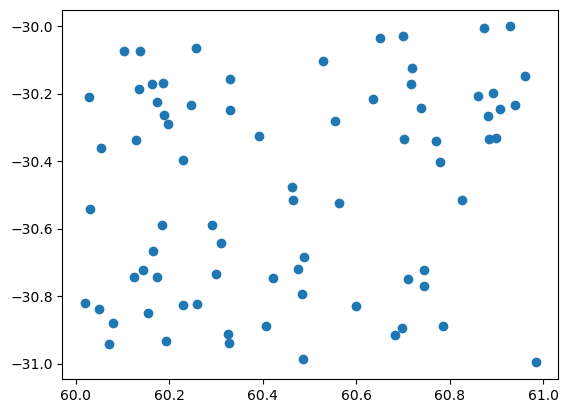

In [59]:
plt.scatter(clusters['ra'], clusters['dec'])
plt.show()

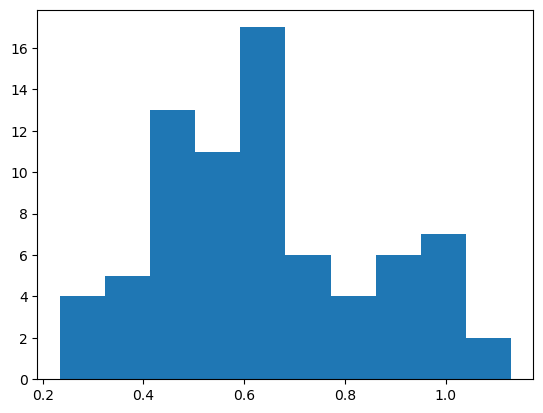

In [62]:
plt.hist(clusters['redshift'])
plt.show()

In [65]:
# This is just an exposures map, really just need something like a footprint that the clusters were found in
hsp_map = hs.HealSparseMap.read('/global/homes/k/kabelo/TXPipe/data/example/inputs/supreme_dc2_dr6d_v2_g_nexp_sum_1deg2.hs')

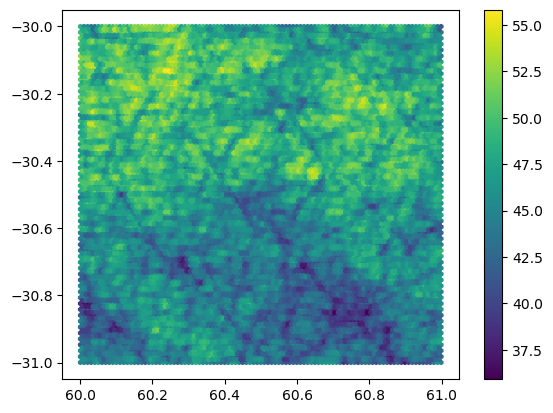

In [66]:
vpix, ra, dec = hsp_map.valid_pixels_pos(return_pixels=True)
plt.hexbin(ra, dec, C=hsp_map[vpix])
plt.colorbar()
plt.show()

In [87]:
ra_r, dec_r = hs.make_uniform_randoms(hsp_map, 100) # random coordinates in the footprint
coords = pd.DataFrame({'ra': ra_r,
                      'dec': dec_r})
# instead of sampling redshift like this, could consider sampling a qpnofz distirbution instead
# both methods make sure randoms have same distribution as data
rz = clusters[['richness', 'redshift', 'scaleval']].sample(n=100, replace=True, random_state=43)
rz.reset_index(drop=True, inplace=True)
random_df = pd.concat([coords, rz], axis=1)
# From this point we can use the scaleval and richness to get an effective richness,
# then compare this to a cutoff richness (a la https://arxiv.org/abs/1601.00621) that acts like a loose detection mask,
# then we only keep the randoms that pass this masking
random_df

,ra,dec,richness,redshift,scaleval
0,60.577777,-30.158605,5.968908,0.596166,1.003070
1,60.002027,-30.777849,5.938398,0.997758,1.000339
2,60.540419,-30.881758,6.716402,0.344936,1.001744
3,60.500595,-30.104671,11.109835,0.573282,1.001301
4,60.437215,-30.583158,6.350283,0.240441,1.001682
...,...,...,...,...,...
95,60.857029,-30.201086,6.655382,0.653051,1.000848
96,60.533403,-30.183608,6.197733,0.638420,1.000909
97,60.904567,-30.954316,6.579107,0.431628,1.000129
98,60.856208,-30.749874,5.602789,0.910142,0.999419


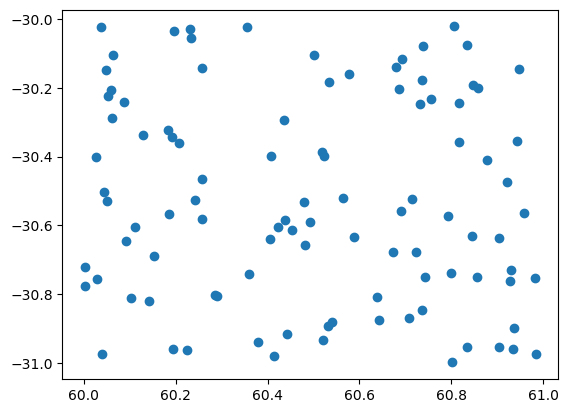

In [90]:
plt.scatter(random_df['ra'], random_df['dec'])
plt.show()